# COURSE: A deep understanding of deep learning
## SECTION: Generative adversarial networks
### LECTURE: Linear GAN with MNIST
#### TEACHER: Mike X Cohen, sincxpress.com
##### COURSE URL: udemy.com/course/deeplearning_x/?couponCode=202401

In [1]:
# import libraries
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms

import sys

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Import the data

In [3]:
# download FMNIST dataset
mnist_train = datasets.FashionMNIST(root='../sample_data/fmnist', download=True, train=True)

# extract labels (number IDs) and data
labels_train = mnist_train.targets.numpy()
data_train = mnist_train.data.numpy().reshape(mnist_train.data.shape[0], -1)  # flatten to 2D

print(labels_train.shape)
print(data_train.shape)

# normalize the data to a range of [0 1]
dataNorm =  (data_train - np.min(data_train)) / (np.max(data_train) - np.min(data_train))
dataNorm = 2*dataNorm - 1 # scale to [-1 1]
print(dataNorm.shape)
print(np.min(dataNorm), np.max(dataNorm))

# convert to tensor
dataT = torch.tensor( dataNorm ).float()

# no dataloaders!
batchsize = 100

(60000,)
(60000, 784)
(60000, 784)
-1.0 1.0


In [4]:
# Create a mapping from class indices to class names and vice versa:
mnist_idx2class = {i: c for i, c in enumerate(mnist_train.classes)}
mnist_class2idx = {c: i for i, c in enumerate(mnist_train.classes)}
print(mnist_idx2class)
print(mnist_class2idx)

{0: 'T-shirt/top', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat', 5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle boot'}
{'T-shirt/top': 0, 'Trouser': 1, 'Pullover': 2, 'Dress': 3, 'Coat': 4, 'Sandal': 5, 'Shirt': 6, 'Sneaker': 7, 'Bag': 8, 'Ankle boot': 9}


In [58]:
# pick three categories (leave one line uncommented)
# classes2keep = [ 'Trouser','Sneaker','Pullover' ]
classes2keep = [ 'Trouser','Sneaker', 'Sandal'  ]

classes2keep_idxs = list(sorted([ mnist_class2idx[c] for c in classes2keep ]))
labels_train_idxs = np.where( np.isin(labels_train, classes2keep_idxs) )[0]
print(labels_train_idxs.shape)
print(labels_train_idxs)

labels_train = labels_train[labels_train_idxs]
dataT = dataT[labels_train_idxs,:]
print(labels_train.shape)
print(dataT.shape)

assert labels_train.shape[0] == dataT.shape[0]


(12000,)
[    1     3     4 ... 17996 17997 17999]
(12000,)
torch.Size([12000, 784])


# Create classes for the discriminator and generator

In [59]:
class discriminatorNet(nn.Module):
  def __init__(self):
    super().__init__()
    torch.manual_seed(41)
    
    self.fc1 = nn.Linear(28*28,256)
    self.fc1_bn = nn.BatchNorm1d(256)
    self.fc2 = nn.Linear(256,256)
    self.fc2_bn = nn.BatchNorm1d(256)
    self.out = nn.Linear(256,1)

  def forward(self,x):
    x = self.fc1(x)
    # x = self.fc1_bn(x)
    x = F.leaky_relu(x)
    
    x = self.fc2(x)
    # x = self.fc2_bn(x)
    x = F.leaky_relu(x)
    x = self.out(x)
    
    return torch.sigmoid( x )

dnet = discriminatorNet()
y = dnet(torch.randn(10,784))
y

tensor([[0.5027],
        [0.5135],
        [0.5185],
        [0.5239],
        [0.4775],
        [0.4834],
        [0.5240],
        [0.5044],
        [0.5215],
        [0.5130]], grad_fn=<SigmoidBackward0>)

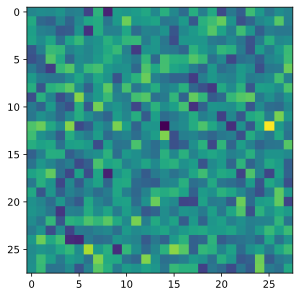

In [60]:
class generatorNet(nn.Module):
  def __init__(self):
    super().__init__()
    torch.manual_seed(42)
    
    self.fc1 = nn.Linear(64,256)
    self.fc1_bn = nn.BatchNorm1d(256)
    self.fc2 = nn.Linear(256,256)
    self.fc2_bn = nn.BatchNorm1d(256)
    self.out = nn.Linear(256,784)

  def forward(self,x):
    x = self.fc1(x)
    # x = self.fc1_bn(x)
    x = F.leaky_relu(x)
    
    x = self.fc2(x)
    # x = self.fc2_bn(x)
    x = F.leaky_relu(x)
    
    x = self.out(x)
    return torch.tanh( x )


gnet = generatorNet()
y = gnet(torch.randn(10,64))
plt.imshow(y[0,:].detach().squeeze().view(28,28));

# Train the models!

In [61]:
# loss function (same for both phases of training)
lossfun = nn.BCELoss()

# create instances of the models
dnet = discriminatorNet().to(device)
gnet = generatorNet().to(device)

# optimizers (same algo but different variables b/c different parameters)
d_optimizer = torch.optim.Adam(dnet.parameters(), lr=.0003)
g_optimizer = torch.optim.Adam(gnet.parameters(), lr=.0003)

In [62]:
# this cell takes ~3 mins with 50k epochs
num_epochs = 50000

losses  = np.zeros((num_epochs,2))
disDecs = np.zeros((num_epochs,2)) # disDecs = discriminator decisions

for epochi in range(num_epochs):
    
  # create minibatches of REAL and FAKE images 
  randidx     = torch.randint(dataT.shape[0],(batchsize,))
  real_images = dataT[randidx,:].to(device)
  fake_images = gnet( torch.randn(batchsize,64).to(device) ) # output of generator


  # labels used for real and fake images
  real_labels = torch.ones(batchsize,1).to(device)
  fake_labels = torch.zeros(batchsize,1).to(device)



  ### ---------------- Train the discriminator ---------------- ###

  # forward pass and loss for REAL pictures
  pred_real   = dnet(real_images)              # REAL images into discriminator
  d_loss_real = lossfun(pred_real,real_labels) # all labels are 1
  
  # forward pass and loss for FAKE pictures
  pred_fake   = dnet(fake_images)              # FAKE images into discriminator
  d_loss_fake = lossfun(pred_fake,fake_labels) # all labels are 0
  
  # collect loss (using combined losses)
  d_loss = d_loss_real + d_loss_fake
  losses[epochi,0]  = d_loss.item()
  disDecs[epochi,0] = torch.mean((pred_real>.5).float()).detach()

  # backprop
  d_optimizer.zero_grad()
  d_loss.backward()
  d_optimizer.step()

  
  

  ### ---------------- Train the generator ---------------- ###

  # create fake images and compute loss
  fake_images = gnet( torch.randn(batchsize,64).to(device) )
  pred_fake   = dnet(fake_images)
  
  # compute and collect loss and accuracy
  g_loss = lossfun(pred_fake,real_labels)
  losses[epochi,1]  = g_loss.item()
  disDecs[epochi,1] = torch.mean((pred_fake>.5).float()).detach()
  
  # backprop
  g_optimizer.zero_grad()
  g_loss.backward()
  g_optimizer.step()

  
  # print out a status message
  if (epochi+1)%500==0:
    msg = f'Finished epoch {epochi+1}/{num_epochs}'
    sys.stdout.write('\r' + msg)

Finished epoch 50000/50000

In [63]:
def smooth1d(x):
    n = 100
    return np.convolve(x, np.ones(n)/n, mode='same')

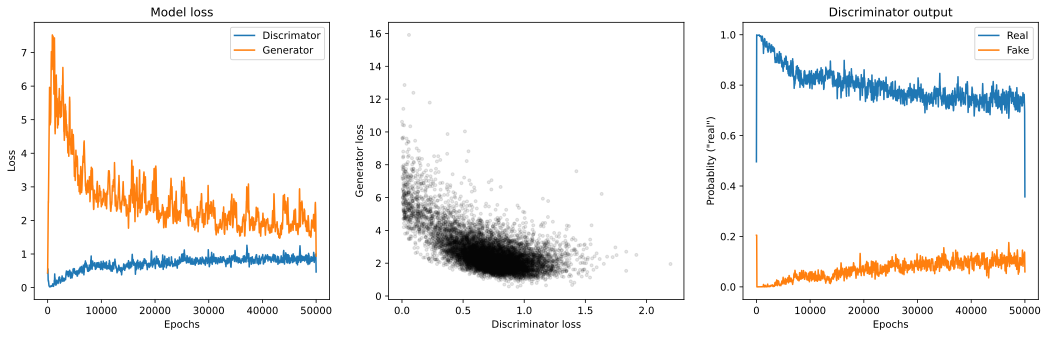

In [64]:
fig,ax = plt.subplots(1,3,figsize=(18,5))

ax[0].plot(smooth1d(losses[:,0]))
ax[0].plot(smooth1d(losses[:,1]))
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_title('Model loss')
ax[0].legend(['Discrimator','Generator'])
# ax[0].set_xlim([4000,5000])

ax[1].plot(losses[::5,0],losses[::5,1],'k.',alpha=.1)
ax[1].set_xlabel('Discriminator loss')
ax[1].set_ylabel('Generator loss')

ax[2].plot(smooth1d(disDecs[:,0]))
ax[2].plot(smooth1d(disDecs[:,1]))
ax[2].set_xlabel('Epochs')
ax[2].set_ylabel('Probablity ("real")')
ax[2].set_title('Discriminator output')
ax[2].legend(['Real','Fake'])

plt.show()

# Let's see some fake digits!

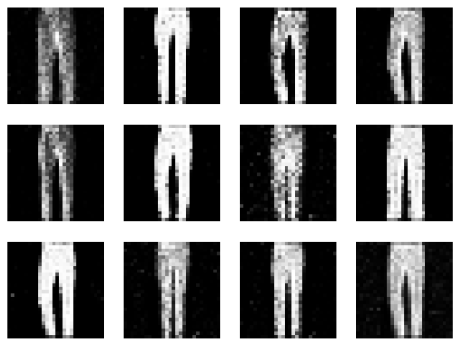

In [78]:
# generate the images from the generator network
gnet.eval()
fake_data = gnet(torch.randn(12,64).to(device)).cpu()

# and visualize...
fig,axs = plt.subplots(3,4,figsize=(8,6))
for i,ax in enumerate(axs.flatten()):
  ax.imshow(fake_data[i,:,].detach().view(28,28),cmap='gray')
  ax.axis('off')

plt.show()